# Lab 1: Reading, Exploring, and Projecting Spatial Data
## ENCN205 - Applied Data Analysis for Civil and Natural Systems
### University of Canterbury | Te Whare Wānanga o Waitaha

**Duration:** 2 hours
**Week:** 2
**Format:** Python (GeoPandas, Matplotlib)

---

### Learning Objectives
By the end of this lab you will be able to:
1. Import and use the core Python geospatial libraries (geopandas, matplotlib, pandas)
2. Read spatial data from multiple file formats (GeoPackage, Shapefile, GeoJSON, CSV)
3. Inspect GeoDataFrame properties including geometry, attributes, and CRS
4. Reproject spatial data between coordinate reference systems
5. Create basic choropleth maps using matplotlib
6. Export spatial data to GeoPackage format

### Prerequisites
- Basic Python (variables, lists, functions)
- Anaconda/Miniconda installed with geopandas


## 1. Setting Up Your Python Environment

Before we start working with spatial data, we need to import the necessary libraries.
The Python geospatial stack builds on several key packages:

| Library | Purpose |
|---------|---------|
| `geopandas` | Spatial DataFrames — extends pandas with geometry |
| `pandas` | Tabular data manipulation |
| `matplotlib` | Static plotting and map visualisation |
| `shapely` | Geometric operations (points, lines, polygons) |

If you get an `ImportError`, install the missing package:
```
conda install -c conda-forge geopandas matplotlib
```


In [1]:
# Import core libraries

import geopandas as gpd
# DB added
import geodatasets
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString, Polygon
import warnings

# Ignore warnings for cleaner output 
warnings.filterwarnings('ignore')

# Check versions
print(f"geopandas version: {gpd.__version__}")
print(f"pandas version:    {pd.__version__}")
print("\n✅ All libraries loaded successfully!")


geopandas version: 1.1.2
pandas version:    2.2.3

✅ All libraries loaded successfully!


## 2. Understanding Geometry Types

Before loading real data, let's understand the three basic geometry types
that represent geographic features:

| Geometry | Real-World Example | Engineering Example |
|----------|-------------------|---------------------|
| **Point** | A location | Borehole, sensor, manhole |
| **LineString** | A path or route | Pipe, road centreline, river |
| **Polygon** | An area | Building footprint, catchment, soil zone |


In [2]:
# Create simple geometries using Shapely
# A Point: University of Canterbury campus (lon, lat in WGS84)

# DB added
# Consider using descriptively named constants rather than using magic numbers in the code.

CAMPUS_COORDS = (172.5833, -43.5226)
ROAD_COORDS = [(172.58, -43.52), (172.59, -43.52), (172.59, -43.53)]

uc_point = Point(CAMPUS_COORDS)
print(f"UC Campus location: {uc_point}")
print(f"  Type:  {uc_point.geom_type}")

# A LineString: a simplified road segment (3 vertices)
road = LineString(ROAD_COORDS)
print(f"\nRoad segment:  {road.geom_type}, length (degrees): {road.length:.4f}")

# A Polygon: a simplified building footprint
# Could ROAD_COORDS be resued here to define the building footprint?
# It would be more efficient and maintainable to reuse existing data rather than hardcoding new coordinates.
building = Polygon([
    (172.583, -43.522), (172.584, -43.522),
    (172.584, -43.523), (172.583, -43.523)
])
print(f"\nBuilding footprint: {building.geom_type}, area (sq degrees): {building.area:.8f}")


UC Campus location: POINT (172.5833 -43.5226)
  Type:  Point

Road segment:  LineString, length (degrees): 0.0200

Building footprint: Polygon, area (sq degrees): 0.00000100


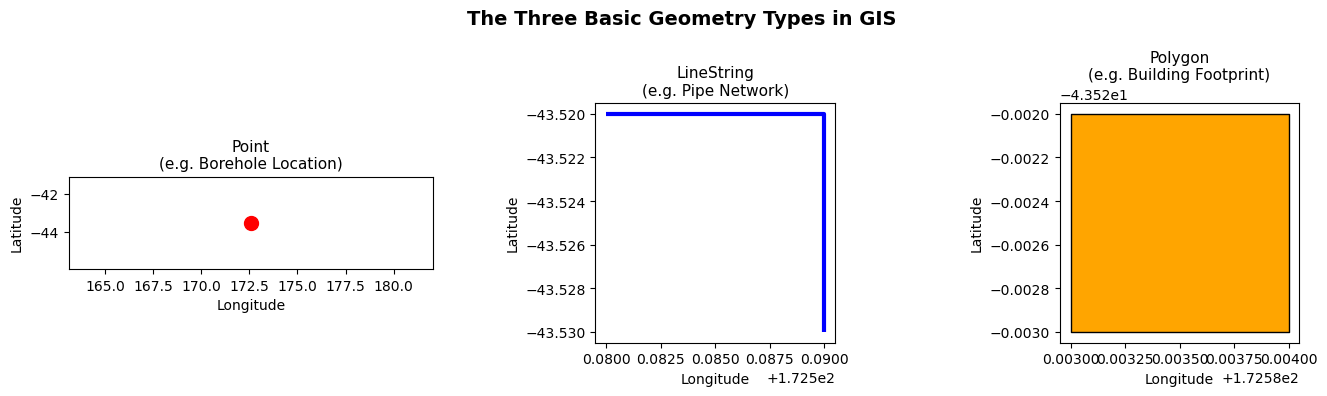

In [3]:
# Visualise the three geometry types
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Plot point
gpd.GeoSeries([uc_point]).plot(ax=axes[0], color='red', markersize=100)
axes[0].set_title("Point\n(e.g. Borehole Location)", fontsize=11)

# Plot line
gpd.GeoSeries([road]).plot(ax=axes[1], color='blue', linewidth=3)
axes[1].set_title("LineString\n(e.g. Pipe Network)", fontsize=11)

# Plot polygon
gpd.GeoSeries([building]).plot(ax=axes[2], color='orange', edgecolor='black')
axes[2].set_title("Polygon\n(e.g. Building Footprint)", fontsize=11)

# DB added.
# Add axis labels to all subplots
for ax in axes:
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.suptitle("The Three Basic Geometry Types in GIS", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 3. Reading Spatial Data from Files

Real-world spatial data comes in many formats. GeoPandas can read most of them
with a single function: `gpd.read_file()`.

### Common Spatial Data Formats

| Format | Extension | Strengths | Limitations |
|--------|-----------|-----------|-------------|
| **GeoPackage** | `.gpkg` | Modern, multi-layer, open standard | Newer — some legacy tools don't support |
| **Shapefile** | `.shp` | Universal support | Multiple files, 10-char field names |
| **GeoJSON** | `.geojson` | Text-based, web-friendly | Large file sizes, WGS84 only |
| **CSV** | `.csv` | Simple, spreadsheet-compatible | No geometry — must create from coords |

### Downloading Sample Data
We'll use the **Natural Earth** built-in dataset to start, then load NZ-specific data.


In [4]:
# ── Read built-in Natural Earth data (ships with geopandas) ──
# DB changed
# world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
# to
world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)
# mimic the old GeoPandas dataset
world = world[
    ['POP_EST', 'CONTINENT', 'NAME', 'ISO_A3', 'GDP_MD', 'geometry']
].rename(columns={
    'POP_EST': 'pop_est',
    'CONTINENT': 'continent',
    'NAME': 'name',
    'ISO_A3': 'iso_a3',
    'GDP_MD': 'gdp_md_est'
})
# End of changes

# Inspect the GeoDataFrame
print(f"Type: {type(world)}")
print(f"Shape: {world.shape}  (rows, columns)")
print(f"CRS:  {world.crs}")
print(f"\nColumn names:")
print(world.columns.tolist())


Type: <class 'geopandas.geodataframe.GeoDataFrame'>
Shape: (177, 6)  (rows, columns)
CRS:  EPSG:4326

Column names:
['pop_est', 'continent', 'name', 'iso_a3', 'gdp_md_est', 'geometry']


In [5]:
# View the first 5 rows
world.head()


,pop_est,continent,name,iso_a3,gdp_md_est,geometry
0,889953.0,Oceania,Fiji,FJI,5496,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,58005463.0,Africa,Tanzania,TZA,63177,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,603253.0,Africa,W. Sahara,ESH,907,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,37589262.0,North America,Canada,CAN,1736425,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,328239523.0,North America,United States of America,USA,21433226,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."


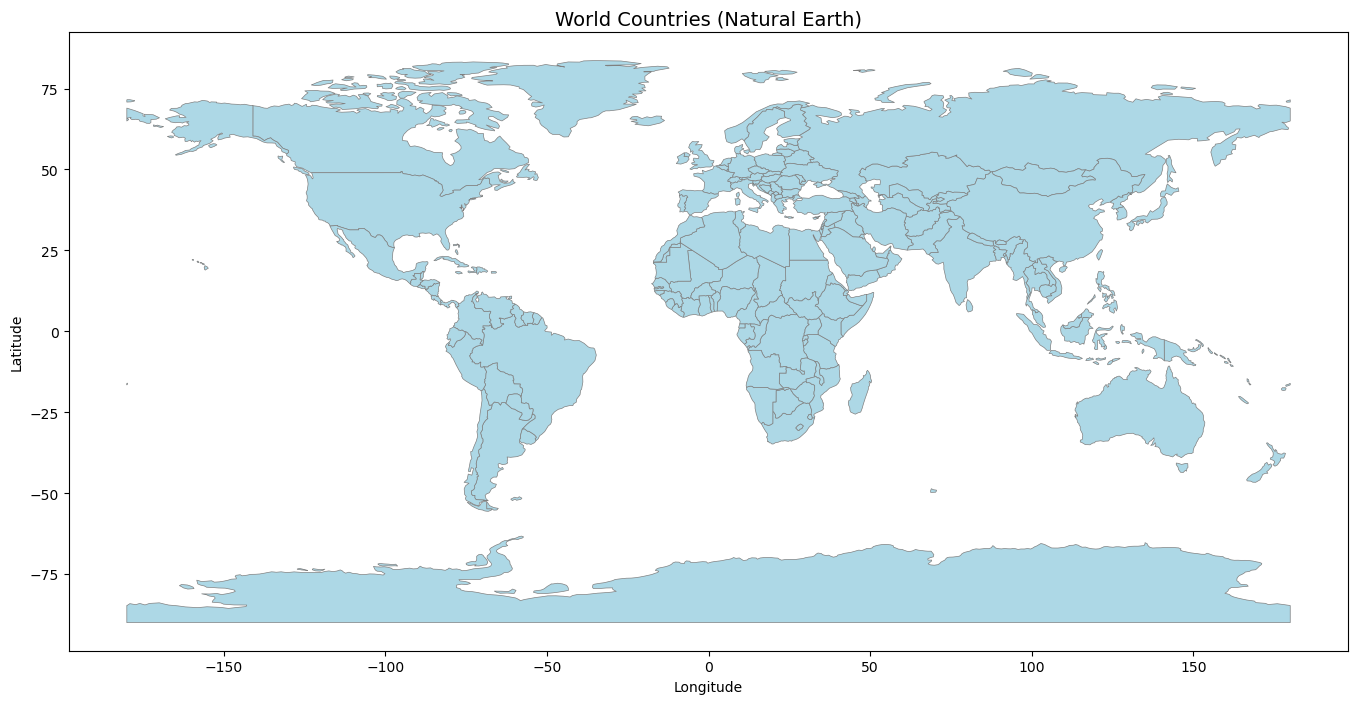

In [6]:
# Quick plot of the world
fig, ax = plt.subplots(figsize=(14, 7))
world.plot(ax=ax, color='lightblue', edgecolor='gray', linewidth=0.5)
ax.set_title("World Countries (Natural Earth)", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()


## 4. Inspecting GeoDataFrame Properties

A `GeoDataFrame` is like a pandas DataFrame but with a special `geometry` column.
Let's explore the key inspection methods every GIS engineer should know.


In [7]:
# Key inspection methods for any GeoDataFrame

# 1. Basic info
print("=== .info() ===")
world.info()


=== .info() ===
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 177 entries, 0 to 176
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   pop_est     177 non-null    float64 
 1   continent   177 non-null    object  
 2   name        177 non-null    object  
 3   iso_a3      177 non-null    object  
 4   gdp_md_est  177 non-null    int32   
 5   geometry    177 non-null    geometry
dtypes: float64(1), geometry(1), int32(1), object(3)
memory usage: 7.7+ KB


In [8]:
# 2. Coordinate Reference System
print(f"CRS: {world.crs}")
print(f"CRS Name: {world.crs.name}")
print(f"EPSG Code: {world.crs.to_epsg()}")


CRS: EPSG:4326
CRS Name: WGS 84
EPSG Code: 4326


In [9]:
# 3. Spatial extent (bounding box)
print(f"Bounds (minx, miny, maxx, maxy):")
print(f"  {world.total_bounds}")

# 4. Geometry types present
print(f"\nGeometry types: {world.geom_type.unique()}")

# 5. Quick statistics on a numeric column
print(f"\nPopulation statistics:")
print(world['pop_est'].describe())


Bounds (minx, miny, maxx, maxy):
  [-180.       -90.       180.        83.64513]

Geometry types: ['MultiPolygon' 'Polygon']

Population statistics:
count    1.770000e+02
mean     4.324346e+07
std      1.513543e+08
min      1.400000e+02
25%      3.301000e+06
50%      1.019232e+07
75%      3.182530e+07
max      1.397715e+09
Name: pop_est, dtype: float64


### 🔧 YOUR TURN: Inspection Practice

Filter the world dataset to just New Zealand and inspect it.


In [ ]:
# 🔧 YOUR TURN — fill in the ... blanks, then run the cell.

# TODO 1: Filter the world GeoDataFrame to select only New Zealand.
#   Same boolean-filter pattern you used above:  gdf[gdf['column'] == value]
#   The country name column is called 'name'.
nz = ...

# TODO 2: Inspect the result — print the number of features, the CRS,
#   and the geometry type.
#   Commands you have already used: len(nz), nz.crs, nz.geom_type.values
print(f"Number of features: {...}")
print(f"CRS: {...}")
print(f"Geometry type: {...}")

# TODO 3: Plot New Zealand.
#   Same as the world plot earlier: nz.plot(ax=ax, color=..., edgecolor=...)
fig, ax = plt.subplots(figsize=(6, 8))
...
ax.set_title("New Zealand", fontsize=14)
plt.tight_layout()
plt.show()


## 5. Creating GeoDataFrames from CSV Coordinates

Engineering data often comes as CSV files with coordinate columns
(e.g., from GPS surveys, sensor networks, or spreadsheets).
We can convert these into spatial data using `gpd.points_from_xy()`.

### Scenario
You have a CSV of borehole locations from a geotechnical investigation
in Christchurch. Each row has Easting and Northing coordinates in NZTM2000.


In [11]:
# Create a sample CSV-like dataset of borehole locations (NZTM2000 coordinates)
borehole_data = pd.DataFrame({
    'bore_id': ['BH-01', 'BH-02', 'BH-03', 'BH-04', 'BH-05',
                'BH-06', 'BH-07', 'BH-08', 'BH-09', 'BH-10'],
    'easting': [1570500, 1571200, 1569800, 1570100, 1571500,
                1570800, 1569500, 1571000, 1570300, 1570700],
    'northing': [5180200, 5180500, 5179800, 5180000, 5180100,
                 5179900, 5180300, 5180600, 5179700, 5180400],
    'depth_m': [12.5, 18.0, 8.5, 15.0, 22.0, 10.0, 14.5, 20.0, 9.0, 16.5],
    'soil_type': ['Silt', 'Sand', 'Clay', 'Gravel', 'Sand',
                  'Silt', 'Clay', 'Sand', 'Peat', 'Gravel'],
    'water_table_m': [2.1, 3.5, 1.2, 4.0, 3.8, 1.8, 0.9, 4.2, 0.5, 3.0]
})

print("Raw borehole data (pandas DataFrame):")
borehole_data.head()


Raw borehole data (pandas DataFrame):


,bore_id,easting,northing,depth_m,soil_type,water_table_m
0,BH-01,1570500,5180200,12.5,Silt,2.1
1,BH-02,1571200,5180500,18.0,Sand,3.5
2,BH-03,1569800,5179800,8.5,Clay,1.2
3,BH-04,1570100,5180000,15.0,Gravel,4.0
4,BH-05,1571500,5180100,22.0,Sand,3.8


In [12]:
# Convert pandas DataFrame to GeoDataFrame using coordinate columns
# NZTM2000 = EPSG:2193
borehole_gdf = gpd.GeoDataFrame(
    borehole_data,
    geometry=gpd.points_from_xy(borehole_data['easting'], borehole_data['northing']),
    crs="EPSG:2193"  # NZTM2000
)

print(f"Type: {type(borehole_gdf)}")
print(f"CRS:  {borehole_gdf.crs}")
print(f"Shape: {borehole_gdf.shape}")
print(f"\nGeometry column sample:")
print(borehole_gdf[['bore_id', 'geometry']].head())


Type: <class 'geopandas.geodataframe.GeoDataFrame'>
CRS:  EPSG:2193
Shape: (10, 7)

Geometry column sample:
  bore_id                 geometry
0   BH-01  POINT (1570500 5180200)
1   BH-02  POINT (1571200 5180500)
2   BH-03  POINT (1569800 5179800)
3   BH-04  POINT (1570100 5180000)
4   BH-05  POINT (1571500 5180100)


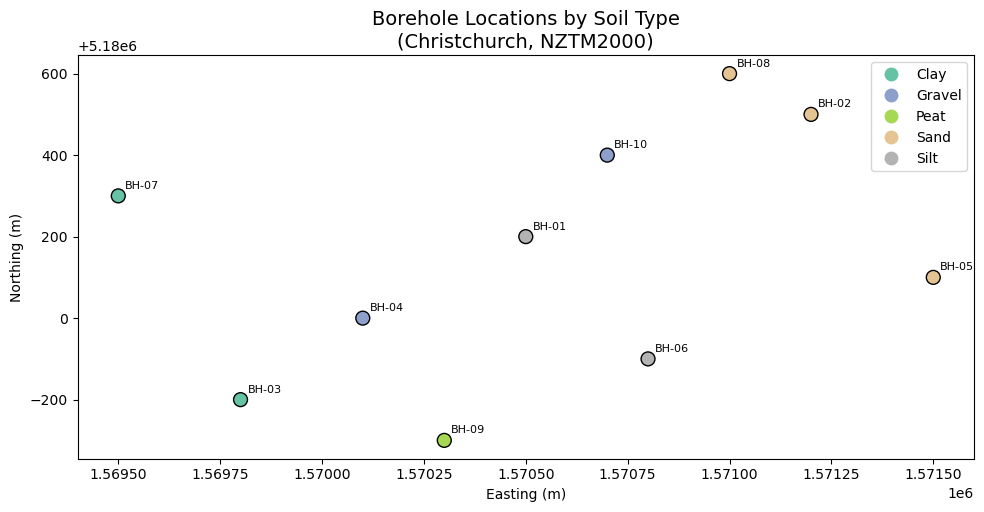

In [13]:
# Plot boreholes coloured by soil type
fig, ax = plt.subplots(figsize=(10, 8))
borehole_gdf.plot(
    ax=ax,
    column='soil_type',
    legend=True,
    markersize=100,
    edgecolor='black',
    cmap='Set2'
)
ax.set_title("Borehole Locations by Soil Type\n(Christchurch, NZTM2000)", fontsize=14)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")

# Add borehole labels
for idx, row in borehole_gdf.iterrows():
    ax.annotate(row['bore_id'], xy=(row.geometry.x, row.geometry.y),
                xytext=(5, 5), textcoords='offset points', fontsize=8)

plt.tight_layout()
plt.show()


## 6. Coordinate Reference Systems and Reprojection

One of the most critical skills in GIS is understanding and managing CRS.
Using the wrong CRS can cause:
- **Misaligned layers** (features don't overlap correctly)
- **Wrong measurements** (distances and areas are incorrect)
- **Failed analyses** (spatial joins produce empty results)

### Key CRS for New Zealand

| CRS | EPSG | Use Case |
|-----|------|----------|
| WGS84 (Geographic) | 4326 | GPS data, web maps, global datasets |
| NZTM2000 (Projected) | 2193 | National mapping, area/distance calculations |
| NZGD2000 (Geographic) | 4167 | NZ-specific geographic coordinates |

### The Rule
> **Always check `.crs` before doing any spatial analysis.
> All layers must share the same CRS for overlays and joins to work.**


In [14]:
# Check the CRS of our borehole data
print(f"Borehole CRS: {borehole_gdf.crs}")
print(f"EPSG code:    {borehole_gdf.crs.to_epsg()}")
print(f"Is projected: {borehole_gdf.crs.is_projected}")
print(f"Units:        {borehole_gdf.crs.axis_info[0].unit_name}")


Borehole CRS: EPSG:2193
EPSG code:    2193
Is projected: True
Units:        metre


In [16]:
# Reproject boreholes from NZTM2000 (EPSG:2193) to WGS84 (EPSG:4326)
borehole_wgs84 = borehole_gdf.to_crs("EPSG:4326")

print("Before reprojection (NZTM2000):")
print(f"  First point: {borehole_gdf.geometry.iloc[0]}")
print(f"  Units: metres")

print(f"\nAfter reprojection (WGS84):")
print(f"  First point: {borehole_wgs84.geometry.iloc[0]}")
print(f"  Units: degrees")


Before reprojection (NZTM2000):
  First point: POINT (1570500 5180200)
  Units: metres

After reprojection (WGS84):
  First point: POINT (172.63491712495502 -43.53055949538417)
  Units: degrees


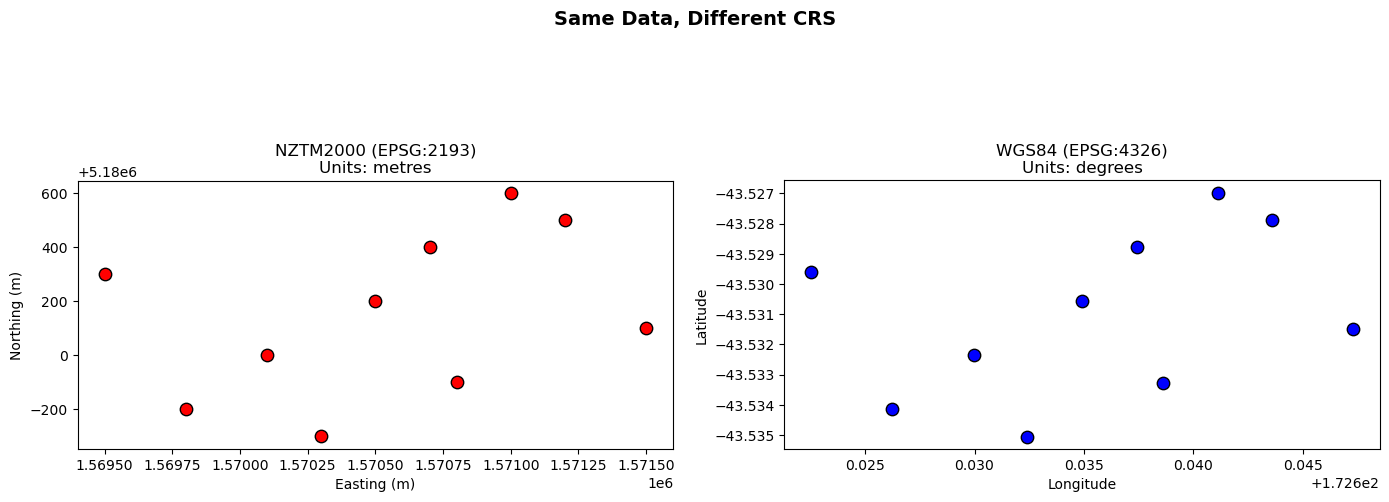

In [17]:
# Visual comparison: same data in two different CRS
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# NZTM2000
borehole_gdf.plot(ax=axes[0], color='red', markersize=80, edgecolor='black')
axes[0].set_title("NZTM2000 (EPSG:2193)\nUnits: metres", fontsize=12)
axes[0].set_xlabel("Easting (m)")
axes[0].set_ylabel("Northing (m)")

# WGS84
borehole_wgs84.plot(ax=axes[1], color='blue', markersize=80, edgecolor='black')
axes[1].set_title("WGS84 (EPSG:4326)\nUnits: degrees", fontsize=12)
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.suptitle("Same Data, Different CRS", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 🔧 YOUR TURN: CRS Practice

Why does the CRS matter for engineering calculations?


In [ ]:
# 🔧 YOUR TURN — the same distance, in two different CRS.

# TODO 1: Get the geometry of BH-01 and BH-02 from borehole_gdf (NZTM2000).
#   Pattern: filter the row, then take its geometry:
#     gdf[gdf['bore_id'] == 'BH-01'].geometry.iloc[0]
bh01_nztm = ...
bh02_nztm = ...

# TODO 2: Calculate the distance between them.
#   NEW command:  geom_a.distance(geom_b)
#   It returns the straight-line distance in the UNITS OF THE CRS.
dist_nztm = ...
print(f"Distance in NZTM2000: {dist_nztm:.1f} metres")

# TODO 3: Repeat both steps with borehole_wgs84 (the reprojected copy).
bh01_wgs = ...
bh02_wgs = ...
dist_wgs = ...
print(f"Distance in WGS84:    {dist_wgs:.6f} degrees")

# TODO 4: Compare the two numbers. Which one could you put in an
#   engineering report, and why? (Write your answer as a comment here.)


## 7. Basic Choropleth Mapping

A **choropleth map** uses colour to represent a quantitative variable across areas.
This is one of the most common map types in engineering and planning.

### Key Parameters for `.plot()`
| Parameter | Description |
|-----------|-------------|
| `column` | The attribute to map |
| `cmap` | Colour map (e.g., 'YlOrRd', 'Blues', 'viridis') |
| `legend` | Show colour legend |
| `scheme` | Classification method ('naturalbreaks', 'equalinterval', 'quantiles') |
| `edgecolor` | Border colour for polygons |


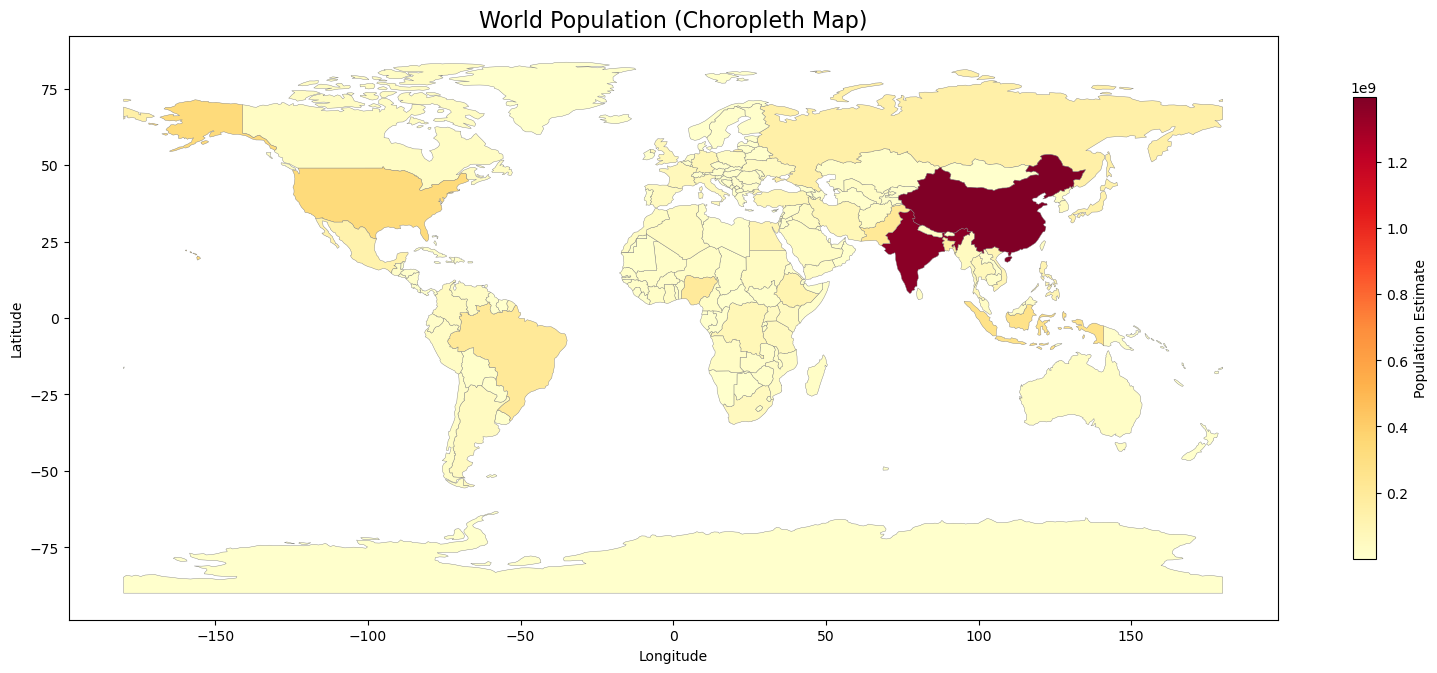

In [18]:
# Choropleth: World population
fig, ax = plt.subplots(figsize=(16, 8))
world.plot(
    ax=ax,
    column='pop_est',
    cmap='YlOrRd',
    legend=True,
    edgecolor='gray',
    linewidth=0.3,
    legend_kwds={'label': 'Population Estimate', 'shrink': 0.6}
)
ax.set_title("World Population (Choropleth Map)", fontsize=16)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()


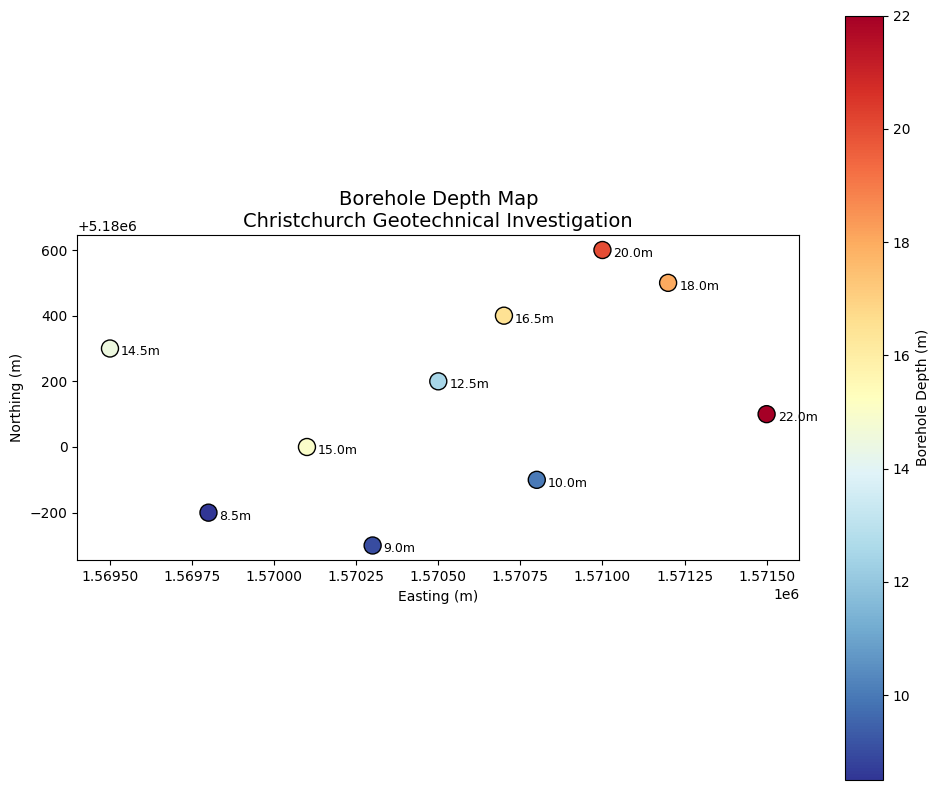

In [24]:
# Choropleth: Boreholes coloured by depth (graduated symbol)
fig, ax = plt.subplots(figsize=(10, 8))
borehole_gdf.plot(
    ax=ax,
    column='depth_m',
    cmap='RdYlBu_r',
    legend=True,
    markersize=150,
    edgecolor='black',
    legend_kwds={'label': 'Borehole Depth (m)'}
)
ax.set_title("Borehole Depth Map\nChristchurch Geotechnical Investigation", fontsize=14)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")

for idx, row in borehole_gdf.iterrows():
    ax.annotate(f"{row['depth_m']}m",
                xy=(row.geometry.x, row.geometry.y),
                xytext=(8, -5), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()


### 🔧 YOUR TURN: Create a Choropleth Map

Create a choropleth map of the boreholes coloured by **water table depth**.
Use the 'Blues_r' colour map (reversed so shallow = dark blue).


In [ ]:
# 🔧 YOUR TURN — choropleth of water table depth.
# Everything you need is in the two choropleth examples above —
# only the column and the colour map change.

fig, ax = plt.subplots(figsize=(10, 8))

# TODO: plot borehole_gdf as a choropleth with
#   column  → 'water_table_m'
#   cmap    → 'Blues_r'   (reversed blues, so shallow = dark blue)
#   legend  → True
#   plus markersize=, edgecolor=, legend_kwds= — copy from the
#   soil-type example and adjust to taste.
borehole_gdf.plot(
    ax=ax,
    column=...,
    cmap=...,
    legend=...,
)

ax.set_title("Water Table Depth Map", fontsize=14)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
plt.tight_layout()
plt.show()


## 8. Writing Spatial Data to GeoPackage

After creating or modifying spatial data, you'll want to save it.
**GeoPackage** (.gpkg) is the recommended modern format:
- Single file (unlike shapefiles)
- Supports multiple layers
- Full CRS support
- No field name length limits


In [22]:
# Save the borehole data to GeoPackage
output_path = "boreholes_christchurch.gpkg"
borehole_gdf.to_file(output_path, driver="GPKG", layer="boreholes")
print(f"✅ Saved {len(borehole_gdf)} features to: {output_path}")

# Verify by reading it back
verify = gpd.read_file(output_path, layer="boreholes")
print(f"\nVerification — read back {len(verify)} features")
print(f"CRS preserved: {verify.crs}")
print(f"Columns: {verify.columns.tolist()}")


✅ Saved 10 features to: boreholes_christchurch.gpkg

Verification — read back 10 features
CRS preserved: EPSG:2193
Columns: ['bore_id', 'easting', 'northing', 'depth_m', 'soil_type', 'water_table_m', 'geometry']


In [23]:
# You can also add another layer to the same GeoPackage
borehole_wgs84.to_file(output_path, driver="GPKG", layer="boreholes_wgs84")
print("✅ Added WGS84 layer to same GeoPackage")

# List layers in the file
import fiona
layers = fiona.listlayers(output_path)
print(f"\nLayers in {output_path}: {layers}")


✅ Added WGS84 layer to same GeoPackage


ModuleNotFoundError: No module named 'fiona'

## 9. Summary and Reflection

### What You Learned Today
1. **Geometry types**: Points, LineStrings, and Polygons represent real-world features
2. **GeoDataFrame**: A spatial DataFrame with geometry + attributes + CRS
3. **Reading data**: `gpd.read_file()` handles GeoPackage, Shapefile, GeoJSON
4. **Creating from CSV**: `gpd.points_from_xy()` converts coordinate columns to geometry
5. **CRS management**: Always check `.crs`, reproject with `.to_crs()`, use EPSG codes
6. **Choropleth maps**: `.plot(column=..., cmap=...)` for thematic mapping
7. **Writing data**: `.to_file()` exports to GeoPackage and other formats

### Key Engineering Takeaways
- **Always use a projected CRS** (like NZTM2000, EPSG:2193) for distance and area calculations
- **Check CRS before any spatial operation** — mismatched CRS = wrong results
- **GeoPackage > Shapefile** for modern workflows

### Reflection Questions
1. When would you choose a Point vs. Polygon representation for the same real-world feature?
2. Why does the CRS matter when calculating the area of a land parcel?
3. What are the advantages of GeoPackage over Shapefile for engineering projects?

---

### Assessment: Lab Sign-Off

**This lab is not complete until you have submitted your sign-off to LEARN.**

**Step 1 — Self-check.** Make sure you can do each of these:

- [ ] Successfully loaded and inspected spatial data
- [ ] Reprojected data between CRS and explained the difference
- [ ] Created at least two choropleth maps
- [ ] Saved data to GeoPackage and verified the output

**Step 2 — Take the sign-off quiz.**

1. Download **`Lab1_SignOff.html`** from LEARN and open it in your web browser.
2. Enter your full name and University ID, then answer the 10 questions.
3. You need **8/10** to pass. You can retake it as often as you like — each
   attempt draws a new set of questions, and every answer comes with an explanation.
4. When you pass, click **Download Sign-Off PNG**. This saves a file called
   `ENCN205_Lab1_<yourID>.png` to your computer.

**Step 3 — Submit.** Upload `ENCN205_Lab1_<yourID>.png` to the **Lab 1 Sign-Off**
submission on LEARN.

> Your PNG records your name, ID, score, and a timestamp, encoded in the QR code.
> It is your proof of completion — show it to your tutor if they ask.
